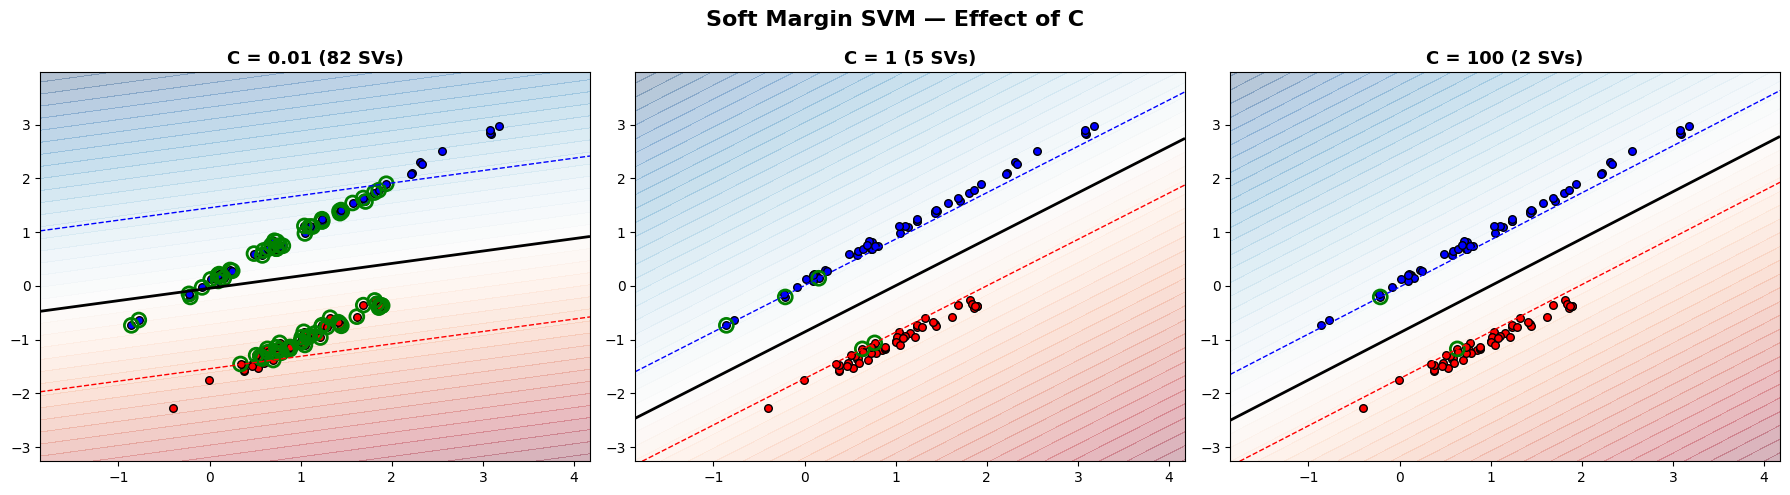

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
y = 2 * y - 1  # Convert to {-1, +1}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
C_values = [0.01, 1, 100]

for ax, C in zip(axes, C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)
    
    # Plot decision boundary
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['red', 'black', 'blue'], linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='red', edgecolor='black', s=30)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', edgecolor='black', s=30)
    
    # Highlight support vectors
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='green', linewidths=2)
    ax.set_title(f'C = {C} ({len(sv)} SVs)', fontsize=13, fontweight='bold')

plt.suptitle('Soft Margin SVM — Effect of C', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_c_values.png', dpi=150)
plt.show()

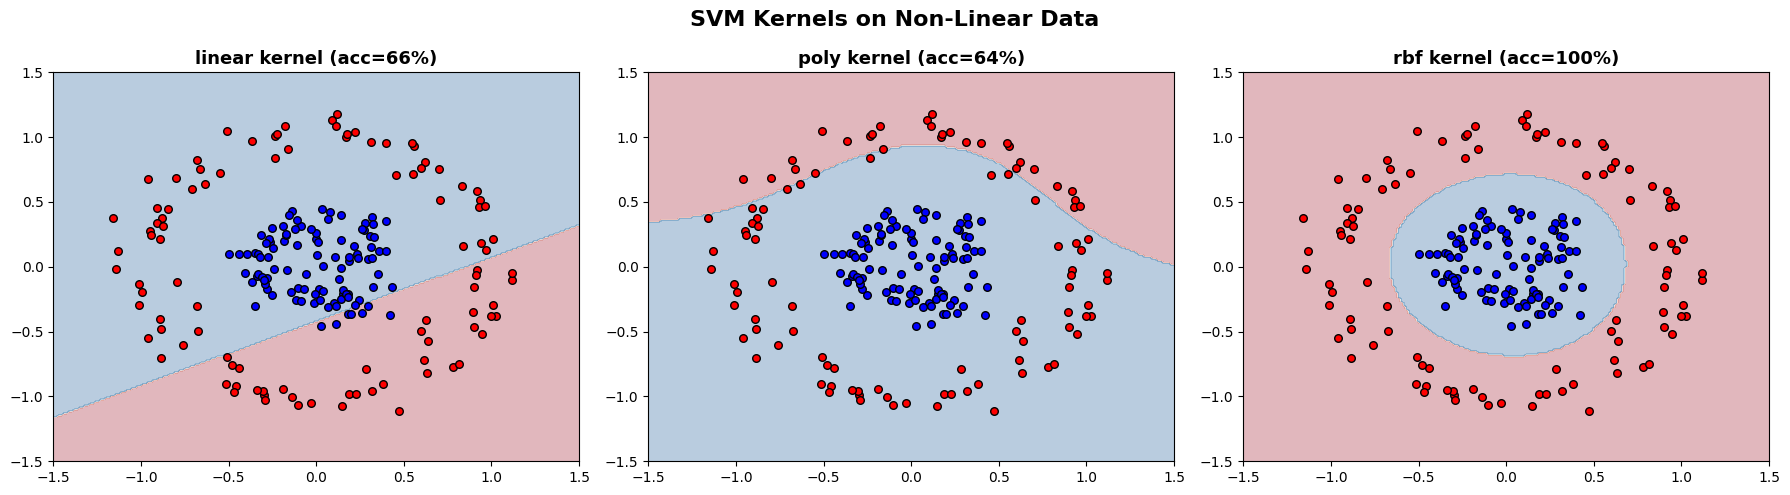

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# Non-linearly separable data
X, y = make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kernels = ['linear', 'poly', 'rbf']

for ax, kernel in zip(axes, kernels):
    model = SVC(kernel=kernel, C=1, gamma='auto', degree=3)
    model.fit(X, y)
    
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, cmap='RdBu', alpha=0.3)
    ax.scatter(X[y==0, 0], X[y==0, 1], c='red', edgecolor='black', s=30)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', edgecolor='black', s=30)
    ax.set_title(f'{kernel} kernel (acc={model.score(X,y):.0%})', fontsize=13, fontweight='bold')

plt.suptitle('SVM Kernels on Non-Linear Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_kernels.png', dpi=150)
plt.show()

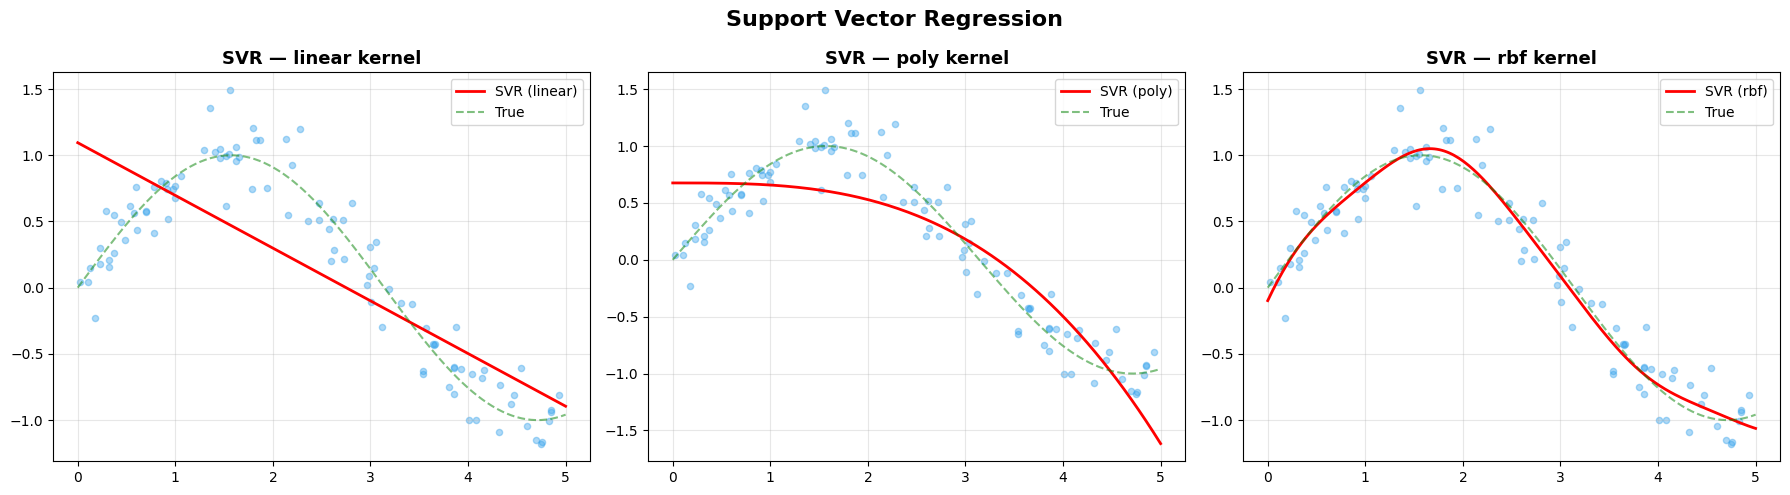

In [3]:
from sklearn.svm import SVR
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.sort(np.random.uniform(0, 5, 100)).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.randn(100) * 0.2

X_plot = np.linspace(0, 5, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kernels = ['linear', 'poly', 'rbf']

for ax, kernel in zip(axes, kernels):
    model = SVR(kernel=kernel, C=100, epsilon=0.1)
    model.fit(X, y)
    y_pred = model.predict(X_plot)
    
    ax.scatter(X, y, alpha=0.4, s=20, color='#36A2EB')
    ax.plot(X_plot, y_pred, 'r-', linewidth=2, label=f'SVR ({kernel})')
    ax.plot(X_plot, np.sin(X_plot.ravel()), 'g--', alpha=0.5, label='True')
    ax.set_title(f'SVR — {kernel} kernel', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Support Vector Regression', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('svr.png', dpi=150)
plt.show()

In [4]:
import numpy as np

class LinearSVMFromScratch:
    """Simple linear SVM using gradient descent on hinge loss."""
    
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Convert labels to {-1, +1}
        y_ = np.where(y <= 0, -1, 1)
        
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    # Correctly classified, just regularize
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Misclassified, update with hinge loss gradient
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * (-y_[idx])
        return self
    
    def predict(self, X):
        output = np.dot(X, self.w) + self.b
        return np.sign(output).astype(int)
    
    def score(self, X, y):
        y_ = np.where(y <= 0, -1, 1)
        return np.mean(self.predict(X) == y_)

# Test
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

svm = LinearSVMFromScratch(learning_rate=0.001, lambda_param=0.01, n_iterations=1000)
svm.fit(X_train_s, y_train)
print(f"From-scratch accuracy: {svm.score(X_test_s, y_test):.2%}")

From-scratch accuracy: 80.00%


In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Grid search for best parameters
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_s, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")
print(f"Test score: {grid.score(X_test_s, y_test):.4f}")

Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9758
Test score: 0.9825
